In [1]:
from datetime import datetime

import torch
from torch.optim import AdamW

from kolmogorov_flow_matching import (
    ConditionalDiffusion,
    ConditionalUnetBackbone,
    NormalizedKolmogorovDataset,
    download_train_set,
    save_checkpoint,
    train_conditional_generative_model,
    visualize_frames,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
print("Downloading/Locating dataset...")
train_h5_path = download_train_set("../data/train")

Downloading/Locating dataset...


Computing global statistics for ../data/train/train/KolmFlow_train_1024.h5...
Done! Mean: 0.00000, Std: 3.50582
Detected target shape: Channels=1, Height=160, Width=160


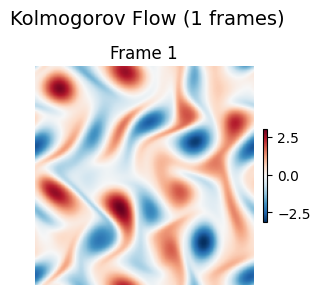

In [3]:
# 1. Configuration
k_frames = 4  # Number of history frames to condition on

# The dataset will automatically compute and print the mean/std on initialization
dataset = NormalizedKolmogorovDataset(
    h5_file_path=train_h5_path, k_frames=k_frames, dataset_key="train/u"
)

# data_shape is [C, H, W] -> For Kolmogorov flow, C=1 usually. H/W depend on the dataset (e.g., 64x64).
# Update data_shape dynamically based on what the dataset returns
sample_batch = dataset[0]
c, h, w = sample_batch["target"].shape
print(f"Detected target shape: Channels={c}, Height={h}, Width={w}")
visualize_frames(sample_batch["target"])

backbone = ConditionalUnetBackbone(data_shape=[c, h, w], k_frames=k_frames).to(device)
model = ConditionalDiffusion(
    backbone=backbone, mean=dataset.mean, std=dataset.std, T=1000
).to(device)

In [ ]:
num_epochs = 5
batch_size = 32
max_grad_norm = 1.0
learn_rate = 1e-4
optimizer = AdamW(model.parameters(), lr=learn_rate)

final_epoch_loss = train_conditional_generative_model(
    model,
    dataset,
    optimizer,
    num_epochs,
    batch_size,
    max_grad_norm,
    num_dataloader_workers=4,
    device=device,
)

Starting training...


Epoch 1/5:   1%|          | 47/6304 [00:44<1:38:15,  1.06it/s, Loss=0.14520]

In [ ]:
dt = datetime.now().strftime("%Y-%m-%d_%H:%M:%S")
save_checkpoint(
    "../checkpoints/diffusion/" + dt + ".pt",
    model,
    optimizer,
    final_epoch_loss,
    num_epochs,
)